<a href="https://colab.research.google.com/github/Rikriti/BioMed-Summarization/blob/main/Biomed_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 RAG vs Standard LLM Summarization — Full Experiment
## Research Question
> **Which retrieval strategy in RAG best preserves factual consistency and medical concept coverage in clinical note summarization — and does the benefit vary by patient risk level?**

---
### Four Pipelines Compared

| Pipeline | Description |
|---|---|
| **A — Standard** | Clinical note → Medical summarizer → Summary |
| **B — Semantic RAG** | FAISS vector retrieval → Augmented prompt → Summary |
| **C — BM25 RAG** | Keyword retrieval → Augmented prompt → Summary |
| **D — Hybrid RAG** | clinical_findings + FAISS + BM25 → Augmented prompt → Summary |

### Five Evaluation Metrics
- **ROUGE-1/2/L** — word overlap with reference summary
- **BERTScore F1** — semantic similarity with reference
- **Faithfulness (NLI)** — are summary claims supported by the source?
- **Medical Concept Score** — are clinical terms preserved?
- **Risk-Stratified Analysis** — does RAG help more for high-risk patients?

---
⚠️ **Before running:** `Runtime → Change runtime type → T4 GPU`

## Cell 1 — Install Dependencies
Run once, then **Runtime → Restart runtime**.

In [1]:
# ============================================================
# CELL 1: Install all required libraries
# After this finishes → Runtime > Restart runtime
# ============================================================

# Step 1: Upgrade transformers to latest (fixes version conflicts)
# ============================================================
# CELL 1: Fix numpy first, then install everything
# ============================================================

# Step 1: Fix numpy binary conflict first
!pip install -q "numpy==1.26.4" --force-reinstall

# Step 2: Install all packages with compatible versions
!pip install -q \
    "transformers==4.44.2" \
    "sentence-transformers==3.0.1" \
    "datasets==2.20.0" \
    "tokenizers==0.19.1" \
    "faiss-cpu==1.7.4" \
    "rouge-score==0.1.2" \
    "bert-score==0.3.13" \
    "rank-bm25==0.2.2" \
    "scipy==1.13.1" \
    "scispacy==0.5.4"

# Step 3: scispaCy model
!pip install -q https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz

print("✅ Done!")
print("⚠️  Now do: Runtime → Disconnect and delete runtime")
print("⚠️  Then reconnect and run from Cell 2 only")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 45.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompat

In [2]:
# Upgrade numpy to 2.0 to match Colab's environment
!pip install -q "numpy>=2.0" --upgrade

# Then reinstall our packages built for numpy 2.0
!pip install -q --upgrade \
    "transformers" \
    "sentence-transformers" \
    "datasets" \
    "faiss-cpu" \
    "rouge-score" \
    "bert-score" \
    "rank-bm25" \
    "scipy" \
    "scispacy"

!pip install -q https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz

print("Done — now Runtime → Disconnect and delete runtime, then reconnect and run Cell 2")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 64.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.0 which is incompatible.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 4.2

In [8]:
!pip uninstall -y spacy thinc scispacy
!pip3 install scispacy

Found existing installation: spacy 3.8.14
Uninstalling spacy-3.8.14:
  Successfully uninstalled spacy-3.8.14
Found existing installation: thinc 8.3.13
Uninstalling thinc-8.3.13:
  Successfully uninstalled thinc-8.3.13
Found existing installation: scispacy 0.6.2
Uninstalling scispacy-0.6.2:
  Successfully uninstalled scispacy-0.6.2
  Using cached scispacy-0.6.2-py3-none-any.whl.metadata (20 kB)
  Using cached spacy-3.8.14-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (28 kB)
  Using cached thinc-8.3.13-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (14 kB)
Using cached scispacy-0.6.2-py3-none-any.whl (62 kB)
Using cached spacy-3.8.14-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (33.2 MB)
Using cached thinc-8.3.13-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following 

## Cell 2 — Imports

In [2]:
# ============================================================
# CELL 2: Import all libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import torch
import json
from tqdm.notebook import tqdm

# Dataset
from datasets import load_dataset

# Summarization
from transformers import pipeline

# Sentence encoder for RAG
from sentence_transformers import SentenceTransformer

# FAISS — vector search engine for Semantic RAG
import faiss

# BM25 — keyword search engine for BM25 RAG
from rank_bm25 import BM25Okapi

# Evaluation metrics
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from scipy import stats

# NLI model for faithfulness scoring
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

# scispaCy for medical concept scoring
import spacy

print("✅ All imports successful!")
print(f"   PyTorch  : {torch.__version__}")
print(f"   GPU      : {torch.cuda.is_available()}")

✅ All imports successful!
   PyTorch  : 2.11.0+cpu
   GPU      : False


## Cell 3 — Load & Inspect Dataset

In [3]:
# ============================================================
# CELL 3: Load dataset and inspect column names
# ============================================================

ds = load_dataset("vickyvamsi22/Clinical_Notes_benchmark_2025")

print("Dataset structure:")
print(ds)

first = ds["train"][0]
print(f"\n📋 Column names: {list(first.keys())}")
print("\n📄 First example preview:")
for k, v in first.items():
    preview = str(v)[:150] + "..." if len(str(v)) > 150 else str(v)
    print(f"  [{k}]: {preview}")

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['id', 'clinical_note', 'visit_context', 'clinical_findings', 'risk_level', 'symptom_duration', 'reference_explanation', 'source_reference'],
        num_rows: 72347
    })
})

📋 Column names: ['id', 'clinical_note', 'visit_context', 'clinical_findings', 'risk_level', 'symptom_duration', 'reference_explanation', 'source_reference']

📄 First example preview:
  [id]: a4034b12-573e-4244-94aa-1935ac833866
  [clinical_note]: Symptoms shows exertional chest pressure relieved by rest. Assessment identifies elevated resting heart rate and irregular pulse rhythm. Hemodynamic p...
  [visit_context]: Cardiology consultation
  [clinical_findings]: exertional chest pressure relieved by rest; elevated resting heart rate; irregular pulse rhythm
  [risk_level]: High
  [symptom_duration]: Ongoing
  [reference_explanation]: Clinical progression indicates imbalance between myocardial oxygen supply and demand affecting cardiac output 

## Cell 4 — Configuration
Column names confirmed from Cell 3 output.

In [4]:
# ============================================================
# CELL 4: Configuration
# ============================================================

# ✅ Confirmed column names from Cell 3
SOURCE_COL    = "clinical_note"          # the clinical note text
REFERENCE_COL = "reference_explanation"  # the gold-standard reference summary
FINDINGS_COL  = "clinical_findings"      # structured facts (used in Hybrid RAG)
RISK_COL      = "risk_level"             # High / Medium / Low (for risk analysis)

# Number of samples (50 is enough to show statistical significance)
N_SAMPLES = 50
SPLIT     = "train"

# ── Slice the dataset ─────────────────────────────────────────
data = ds[SPLIT].select(range(min(N_SAMPLES, len(ds[SPLIT]))))

sources    = [ex[SOURCE_COL]    for ex in data]
references = [ex[REFERENCE_COL] for ex in data]
findings   = [ex[FINDINGS_COL]  for ex in data]
risk_levels= [ex[RISK_COL]      for ex in data]

print(f"✅ {len(sources)} samples loaded from '{SPLIT}' split")
print(f"\n📄 Source preview   : {sources[0][:200]}...")
print(f"📋 Reference preview : {references[0][:200]}...")
print(f"🔬 Findings preview  : {findings[0][:200]}...")
print(f"⚠️  Risk levels found : {set(risk_levels)}")

✅ 50 samples loaded from 'train' split

📄 Source preview   : Symptoms shows exertional chest pressure relieved by rest. Assessment identifies elevated resting heart rate and irregular pulse rhythm. Hemodynamic parameters remain stable....
📋 Reference preview : Clinical progression indicates imbalance between myocardial oxygen supply and demand affecting cardiac output efficiency. Temporal classification as ongoing aligns with the documented objective featur...
🔬 Findings preview  : exertional chest pressure relieved by rest; elevated resting heart rate; irregular pulse rhythm...
⚠️  Risk levels found : {'Low', 'High', 'Moderate'}


In [6]:
!pip uninstall -y spacy thinc scispacy en-core-sci-sm en-core-web-sm
!pip cache purge

Found existing installation: spacy 3.8.14
Uninstalling spacy-3.8.14:
  Successfully uninstalled spacy-3.8.14
Found existing installation: thinc 8.3.13
Uninstalling thinc-8.3.13:
  Successfully uninstalled thinc-8.3.13
Found existing installation: scispacy 0.6.2
Uninstalling scispacy-0.6.2:
  Successfully uninstalled scispacy-0.6.2
Found existing installation: en_core_sci_sm 0.5.4
Uninstalling en_core_sci_sm-0.5.4:
  Successfully uninstalled en_core_sci_sm-0.5.4
Found existing installation: en_core_web_sm 3.8.0
Uninstalling en_core_web_sm-3.8.0:
  Successfully uninstalled en_core_web_sm-3.8.0
Files removed: 168


## Cell 5 — Load Models
Four models are loaded:
1. **Medical Summarizer** — trained on medical text (not news like distilBART)
2. **Sentence Encoder** — converts sentences to vectors for Semantic RAG
3. **NLI Model** — checks if summary claims are supported by the source
4. **scispaCy** — extracts medical concepts (drugs, conditions, procedures)

In [7]:
# ============================================================
# CELL 5: Load all models
# Takes 3-5 minutes on first run
# ============================================================

import spacy

# ── Model 1: Medical Summarizer (direct loading, no pipeline) ─
from transformers import BartTokenizer, BartForConditionalGeneration

print("[1/4] Loading summarizer: facebook/bart-large-cnn ...")
bart_tokenizer = BartTokenizer.from_pretrained("facebook/bart-large-cnn")
bart_model     = BartForConditionalGeneration.from_pretrained("facebook/bart-large-cnn")
bart_model.eval()
print("      ✅ Summarizer ready")

# ── Model 2: Sentence Encoder for Semantic RAG ────────────────
# Converts sentences into 384-dim vectors for FAISS retrieval.
print("[2/4] Loading sentence encoder: all-MiniLM-L6-v2 ...")
encoder = SentenceTransformer("all-MiniLM-L6-v2")
print("      ✅ Sentence encoder ready")

# ── Model 3: NLI Model for Faithfulness ──────────────────────
# Checks if each summary sentence is entailed by the source.
print("[3/4] Loading NLI model: cross-encoder/nli-deberta-v3-small ...")
nli_tokenizer = AutoTokenizer.from_pretrained("cross-encoder/nli-deberta-v3-small")
nli_model     = AutoModelForSequenceClassification.from_pretrained(
                    "cross-encoder/nli-deberta-v3-small")
nli_model.eval()
print("      ✅ NLI model ready")

# ── Model 4: scispaCy for Medical Concept Scoring ─────────────
# Extracts biomedical entities: diseases, drugs, procedures.
# Falls back to standard spaCy if scispaCy model unavailable.
print("[4/4] Loading scispaCy model ...")
try:
    nlp = spacy.load("en_core_sci_sm")
    print("      ✅ scispaCy en_core_sci_sm ready")
except OSError:
    print("      ⚠️  en_core_sci_sm not found, trying en_core_web_sm fallback...")
    try:
        import subprocess
        subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"], check=True)
        nlp = spacy.load("en_core_web_sm")
        print("      ✅ Fallback en_core_web_sm loaded (general English NER)")
    except Exception as e2:
        print(f"      ❌ Could not load any spaCy model: {e2}")
        nlp = None

print("\n🎉 All models loaded!")


[1/4] Loading summarizer: facebook/bart-large-cnn ...


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

      ✅ Summarizer ready
[2/4] Loading sentence encoder: all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

      ✅ Sentence encoder ready
[3/4] Loading NLI model: cross-encoder/nli-deberta-v3-small ...


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

      ✅ NLI model ready
[4/4] Loading scispaCy model ...
      ⚠️  en_core_sci_sm not found, trying en_core_web_sm fallback...
      ❌ Could not load any spaCy model: Command '['python', '-m', 'spacy', 'download', 'en_core_web_sm']' returned non-zero exit status 1.

🎉 All models loaded!


## Cell 6 — Helper Functions
All the building blocks for the four pipelines and five metrics.

In [11]:
# ============================================================
# CELL 6: Helper functions
# ============================================================

MAX_INPUT_WORDS = 400   # conservative limit for medical summarizer
SUMMARY_MIN     = 30
SUMMARY_MAX     = 130
TOP_K           = 5     # sentences to retrieve in RAG


# ── 1. Sentence splitter ──────────────────────────────────────
def split_into_sentences(text: str) -> list:
    """Splits text into a list of sentences on '. ' boundaries."""
    return [s.strip() for s in text.replace("\n", " ").split(". ") if s.strip()]


# ── 2. Safe summarizer ────────────────────────────────────────
def safe_summarize(text: str) -> str:
    """
    Summarizes text using BART directly without pipeline.
    """
    words = text.split()
    if len(words) > MAX_INPUT_WORDS:
        text = " ".join(words[:MAX_INPUT_WORDS])

    inputs = bart_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        summary_ids = bart_model.generate(
            inputs["input_ids"],
            min_length=SUMMARY_MIN,
            max_length=SUMMARY_MAX,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3
        )

    return bart_tokenizer.decode(summary_ids[0], skip_special_tokens=True)


# ── 3. Semantic RAG retrieval (FAISS) ─────────────────────────
def retrieve_semantic(source_text: str, k: int = TOP_K) -> str:
    """
    Pipeline B — Semantic RAG.

    How it works:
      1. Split document into sentences
      2. Embed every sentence into a vector (MiniLM)
      3. Build a FAISS index over those vectors
      4. Use the full document embedding as the search query
      5. Return the top-k most semantically central sentences

    WHY: The full-document vector captures the main topic.
    Retrieved sentences are the most information-dense parts of the note.
    """
    sentences = split_into_sentences(source_text)
    if not sentences:
        return source_text

    embeddings = encoder.encode(sentences, convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(embeddings)

    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)

    query = encoder.encode([source_text], convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(query)

    k_actual = min(k, len(sentences))
    _, indices = index.search(query, k_actual)

    retrieved = [sentences[i] for i in sorted(indices[0])]
    return ". ".join(retrieved)


# ── 4. BM25 RAG retrieval (keyword-based) ────────────────────
def retrieve_bm25(source_text: str, k: int = TOP_K) -> str:
    """
    Pipeline C — BM25 RAG.

    How it works:
      1. Split document into sentences
      2. Tokenize each sentence into words
      3. Build a BM25 index (like a mini search engine)
      4. Use the full document's words as the query
      5. Return the top-k highest-scoring sentences

    WHY BM25 is different from FAISS:
      FAISS finds sentences by MEANING (semantic similarity).
      BM25 finds sentences by KEYWORD OVERLAP (term frequency).
      Medical notes are full of specific terms (drug names, measurements)
      that BM25 is very good at matching — which FAISS might miss.
    """
    sentences = split_into_sentences(source_text)
    if not sentences:
        return source_text

    tokenized_sents = [s.lower().split() for s in sentences]
    bm25            = BM25Okapi(tokenized_sents)
    query_tokens    = source_text.lower().split()
    scores          = bm25.get_scores(query_tokens)

    k_actual = min(k, len(sentences))
    top_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:k_actual]

    retrieved = [sentences[i] for i in sorted(top_indices)]
    return ". ".join(retrieved)


# ── 5. Hybrid RAG prompt builder ─────────────────────────────
def build_hybrid_prompt(source_text: str, clinical_findings: str) -> str:
    """
    Pipeline D — Hybrid RAG.

    Combines THREE sources of grounding:
      1. clinical_findings column  → structured, pre-extracted facts
      2. BM25 retrieved sentences  → keyword-matched sentences
      3. FAISS retrieved sentences → semantically central sentences

    WHY this is stronger:
      structured facts  → ensures key diagnoses/findings are explicit
      BM25              → catches specific medical terms
      FAISS             → catches thematic/contextual sentences
      Together they leave very little room for hallucination.
    """
    semantic_context = retrieve_semantic(source_text, k=3)
    bm25_context     = retrieve_bm25(source_text, k=3)

    prompt = (
        f"Structured clinical findings:\n{clinical_findings}\n\n"
        f"Key facts (semantic retrieval):\n{semantic_context}\n\n"
        f"Key facts (keyword retrieval):\n{bm25_context}\n\n"
        f"Full clinical note:\n{source_text}"
    )
    return prompt


# ── 6. Faithfulness score (NLI) ──────────────────────────────
def faithfulness_score(source: str, summary: str) -> float:
    """
    For every sentence in the summary, asks the NLI model:
      'Is this sentence entailed (supported) by the source?'

    Returns mean P(entailment) across all summary sentences.
    Score range: 0 (hallucinated) to 1 (fully supported).
    This is the PRIMARY metric for your research question.
    """
    sents = split_into_sentences(summary)
    if not sents:
        return 0.0

    src = " ".join(source.split()[:350])   # truncate for NLI context window

    scores = []
    for sent in sents:
        enc = nli_tokenizer(
            src, sent,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )
        with torch.no_grad():
            logits = nli_model(**enc).logits
        probs = F.softmax(logits, dim=-1).squeeze()
        scores.append(probs[1].item())   # index 1 = entailment

    return float(np.mean(scores))


# ── 7. Medical concept score (scispaCy) ──────────────────────
# ── 7. Medical concept score (keyword-based, no spaCy) ────────
MEDICAL_TERMS = [
    "pain", "pressure", "heart", "cardiac", "chest", "blood", "rate",
    "pulse", "rhythm", "stable", "elevated", "irregular", "diagnosis",
    "treatment", "symptoms", "patient", "clinical", "acute", "chronic",
    "medication", "drug", "dose", "fever", "infection", "inflammation",
    "glucose", "oxygen", "respiratory", "hypertension", "diabetes"
]

def medical_concept_score(source: str, summary: str) -> float:
    source_lower  = source.lower()
    summary_lower = summary.lower()
    source_terms  = set(t for t in MEDICAL_TERMS if t in source_lower)
    if not source_terms:
        return 1.0
    preserved = set(t for t in source_terms if t in summary_lower)
    return len(preserved) / len(source_terms)

print("✅ medical_concept_score updated — no spaCy needed")


# ── 8. ROUGE scorer ──────────────────────────────────────────
rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def compute_rouge(hypothesis: str, reference: str) -> dict:
    s = rouge.score(reference, hypothesis)
    return {
        "rouge1": s["rouge1"].fmeasure,
        "rouge2": s["rouge2"].fmeasure,
        "rougeL": s["rougeL"].fmeasure,
    }


print("✅ All helper functions defined")

✅ medical_concept_score updated — no spaCy needed
✅ All helper functions defined


## Cell 7 — Run the Experiment
Main loop: runs all four pipelines on every sample and scores them.

⏱️ *Estimated time: ~5–15 minutes for 50 samples depending on device.*

In [12]:
# ============================================================
# CELL 7: Main experiment loop — four pipelines, five metrics
# ============================================================

results = []

for i, (source, reference, finding, risk) in enumerate(tqdm(
        zip(sources, references, findings, risk_levels),
        total=len(sources),
        desc="Running pipelines")):

    # ════════════════════════════════════════════════════════
    # PIPELINE A: Standard Summarization
    # No retrieval — raw note goes directly to summarizer.
    # This is the baseline every other pipeline is compared to.
    # ════════════════════════════════════════════════════════

    std_summary = safe_summarize(source)

    # ════════════════════════════════════════════════════════
    # PIPELINE B: Semantic RAG (FAISS)
    # Retrieves the most semantically central sentences using
    # vector similarity, prepends them as context.
    # ════════════════════════════════════════════════════════
    sem_context = retrieve_semantic(source, k=TOP_K)
    sem_prompt  = (
        f"Key facts from the document:\n{sem_context}\n\n"
        f"Full clinical note:\n{source}"
    )
    sem_summary = safe_summarize(sem_prompt)

    # ════════════════════════════════════════════════════════
    # PIPELINE C: BM25 RAG (Keyword-based)
    # Retrieves sentences with the highest keyword overlap.
    # Better at preserving specific medical terms than FAISS.
    # ════════════════════════════════════════════════════════
    bm25_context = retrieve_bm25(source, k=TOP_K)
    bm25_prompt  = (
        f"Key facts from the document:\n{bm25_context}\n\n"
        f"Full clinical note:\n{source}"
    )
    bm25_summary = safe_summarize(bm25_prompt)

    # ════════════════════════════════════════════════════════
    # PIPELINE D: Hybrid RAG
    # Combines structured clinical_findings + FAISS + BM25.
    # The richest context — leaves least room for hallucination.
    # ════════════════════════════════════════════════════════
    hybrid_prompt   = build_hybrid_prompt(source, finding)
    hybrid_summary  = safe_summarize(hybrid_prompt)

    # ════════════════════════════════════════════════════════
    # EVALUATION — score all four summaries on four metrics
    # BERTScore is done in batch in the next cell (more efficient)
    # ════════════════════════════════════════════════════════

    def score_summary(summary):
        rouge_scores = compute_rouge(summary, reference)
        return {
            **rouge_scores,
            "faithfulness"    : faithfulness_score(source, summary),
            "medical_concept" : medical_concept_score(source, summary),
        }

    std_scores    = score_summary(std_summary)
    sem_scores    = score_summary(sem_summary)
    bm25_scores   = score_summary(bm25_summary)
    hybrid_scores = score_summary(hybrid_summary)

    results.append({
        "id"        : i,
        "risk_level": risk,
        "source"    : source,
        "reference" : reference,

        # Summaries
        "std_summary"   : std_summary,
        "sem_summary"   : sem_summary,
        "bm25_summary"  : bm25_summary,
        "hybrid_summary": hybrid_summary,

        # ROUGE
        "std_rouge1"    : std_scores["rouge1"],
        "std_rouge2"    : std_scores["rouge2"],
        "std_rougeL"    : std_scores["rougeL"],
        "sem_rouge1"    : sem_scores["rouge1"],
        "sem_rouge2"    : sem_scores["rouge2"],
        "sem_rougeL"    : sem_scores["rougeL"],
        "bm25_rouge1"   : bm25_scores["rouge1"],
        "bm25_rouge2"   : bm25_scores["rouge2"],
        "bm25_rougeL"   : bm25_scores["rougeL"],
        "hyb_rouge1"    : hybrid_scores["rouge1"],
        "hyb_rouge2"    : hybrid_scores["rouge2"],
        "hyb_rougeL"    : hybrid_scores["rougeL"],

        # Faithfulness (NLI)
        "std_faith"  : std_scores["faithfulness"],
        "sem_faith"  : sem_scores["faithfulness"],
        "bm25_faith" : bm25_scores["faithfulness"],
        "hyb_faith"  : hybrid_scores["faithfulness"],

        # Medical Concept Score
        "std_med"    : std_scores["medical_concept"],
        "sem_med"    : sem_scores["medical_concept"],
        "bm25_med"   : bm25_scores["medical_concept"],
        "hyb_med"    : hybrid_scores["medical_concept"],
    })

df = pd.DataFrame(results)
print(f"\n✅ Experiment complete — {len(df)} samples processed")
df[["std_faith", "sem_faith", "bm25_faith", "hyb_faith",
    "std_med",   "sem_med",   "bm25_med",   "hyb_med"]].head(3)

Running pipelines:   0%|          | 0/50 [00:00<?, ?it/s]


✅ Experiment complete — 50 samples processed


,std_faith,sem_faith,bm25_faith,hyb_faith,std_med,sem_med,bm25_med,hyb_med
0,0.302289,0.302289,0.302289,0.367549,1.0,1.0,1.0,0.9
1,0.150091,0.150091,0.150091,0.404829,1.0,1.0,1.0,1.0
2,0.319837,0.172181,0.172181,0.172181,1.0,1.0,1.0,1.0


## Cell 8 — BERTScore (Batch)

In [13]:
# ============================================================
# CELL 8: BERTScore — computed in batch for all four pipelines
#
# BERTScore uses contextual BERT embeddings to measure semantic
# similarity between a generated summary and the reference.
# It catches paraphrased correct content that ROUGE would miss.
# ============================================================

refs = df["reference"].tolist()

pipelines_bert = {
    "std" : df["std_summary"].tolist(),
    "sem" : df["sem_summary"].tolist(),
    "bm25": df["bm25_summary"].tolist(),
    "hyb" : df["hybrid_summary"].tolist(),
}

for name, summaries in pipelines_bert.items():
    print(f"Computing BERTScore for {name} pipeline...")
    _, _, f1 = bert_score(summaries, refs, lang="en", verbose=False)
    df[f"{name}_bert"] = f1.numpy()

print("\n✅ BERTScore computed for all four pipelines")

Computing BERTScore for std pipeline...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Computing BERTScore for hyb pipeline...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ BERTScore computed for all four pipelines


## Cell 9 — Aggregated Results Table

In [15]:
# ============================================================
# CELL 9: Aggregated results — all four pipelines, all five metrics
# ============================================================

pipeline_names = {
    "std" : "A — Standard",
    "sem" : "B — Semantic RAG",
    "bm25": "C — BM25 RAG",
    "hyb" : "D — Hybrid RAG",
}

metric_cols = {
    "ROUGE-1"         : "rouge1",
    "ROUGE-2"         : "rouge2",
    "ROUGE-L"         : "rougeL",
    "BERTScore F1"    : "bert",
    "Faithfulness"    : "faith",
    "Medical Concept" : "med",
}

rows = []
for p_key, p_name in pipeline_names.items():
    row = {"Pipeline": p_name}
    for m_name, m_key in metric_cols.items():
        col = f"{p_key}_{m_key}"
        row[m_name] = round(df[col].mean(), 4) if col in df.columns else "N/A"
    rows.append(row)

results_table = pd.DataFrame(rows).set_index("Pipeline")

print("\n📊 AGGREGATED RESULTS — Mean scores over all samples")
print("=" * 75)
display(results_table)

# Find best pipeline per metric
print("\n🏆 Best pipeline per metric:")
for m in metric_cols.keys():
    best = results_table[m].idxmax()
    print(f"   {m:<20}: {best}  ({results_table.loc[best, m]})")


📊 AGGREGATED RESULTS — Mean scores over all samples


,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore F1,Faithfulness,Medical Concept
Pipeline,,,,,,
A — Standard,0.0800,0.0000,0.0678,0.8461,0.2309,0.9900
B — Semantic RAG,0.0950,0.0064,0.0790,0.8463,0.2023,0.9933
C — BM25 RAG,0.0950,0.0064,0.0790,0.8463,0.2023,0.9933
D — Hybrid RAG,0.0689,0.0000,0.0578,0.8391,0.2954,0.9523



🏆 Best pipeline per metric:
   ROUGE-1             : B — Semantic RAG  (0.095)
   ROUGE-2             : B — Semantic RAG  (0.0064)
   ROUGE-L             : B — Semantic RAG  (0.079)
   BERTScore F1        : B — Semantic RAG  (0.8463000059127808)
   Faithfulness        : D — Hybrid RAG  (0.2954)
   Medical Concept     : B — Semantic RAG  (0.9933)


## Cell 10 — Statistical Significance
Paired t-tests comparing each RAG pipeline against the Standard baseline.
**p < 0.05** = the improvement is real, not random.

In [16]:
# ============================================================
# CELL 10: Paired t-tests — each RAG pipeline vs Standard baseline
#
# WHY paired t-test?
#   Each clinical note is scored by ALL four pipelines.
#   A paired test accounts for this within-sample correlation
#   and is more statistically powerful than independent tests.
# ============================================================

rag_pipelines = {
    "B — Semantic RAG": "sem",
    "C — BM25 RAG"    : "bm25",
    "D — Hybrid RAG"  : "hyb",
}

faith_metric = "faith"
med_metric   = "med"
bert_metric  = "bert"

sig_rows = []
for p_name, p_key in rag_pipelines.items():
    for m_name, m_key in [("Faithfulness", faith_metric),
                           ("Medical Concept", med_metric),
                           ("BERTScore", bert_metric)]:
        std_col = f"std_{m_key}"
        rag_col = f"{p_key}_{m_key}"
        if std_col not in df.columns or rag_col not in df.columns:
            continue
        t_stat, p_val = stats.ttest_rel(df[rag_col], df[std_col])
        sig_rows.append({
            "Pipeline"    : p_name,
            "Metric"      : m_name,
            "Std Mean"    : round(df[std_col].mean(), 4),
            "RAG Mean"    : round(df[rag_col].mean(), 4),
            "Delta"       : round(df[rag_col].mean() - df[std_col].mean(), 4),
            "t-statistic" : round(t_stat, 3),
            "p-value"     : round(p_val, 4),
            "Significant?": "✅ Yes" if p_val < 0.05 else "❌ No",
        })

sig_df = pd.DataFrame(sig_rows)
print("\n📐 Statistical Significance (Paired t-test vs Standard baseline)")
print("=" * 80)
display(sig_df.set_index(["Pipeline", "Metric"]))


📐 Statistical Significance (Paired t-test vs Standard baseline)


Std Mean  RAG Mean   Delta  t-statistic  \
Pipeline         Metric                                                     
B — Semantic RAG Faithfulness       0.2309    0.2023 -0.0285       -2.419   
                 Medical Concept    0.9900    0.9933  0.0033        0.275   
                 BERTScore          0.8461    0.8463  0.0002        0.651   
C — BM25 RAG     Faithfulness       0.2309    0.2023 -0.0285       -2.419   
                 Medical Concept    0.9900    0.9933  0.0033        0.275   
                 BERTScore          0.8461    0.8463  0.0002        0.651   
D — Hybrid RAG   Faithfulness       0.2309    0.2954  0.0645        2.068   
                 Medical Concept    0.9900    0.9523 -0.0377       -2.308   
                 BERTScore          0.8461    0.8391 -0.0070       -4.666   

                                  p-value Significant?  
Pipeline         Metric                                 
B — Semantic RAG Faithfulness      0.0193        ✅ Yes  
                 Medical Concept   0.7846         ❌ No  
                 BERTScore         0.5178         ❌ No  
C — BM25 RAG     Faithfulness      0.0193        ✅ Yes  
                 Medical Concept   0.7846         ❌ No  
                 BERTScore         0.5178         ❌ No  
D — Hybrid RAG   Faithfulness      0.0439        ✅ Yes  
                 Medical Concept   0.0253        ✅ Yes  
                 BERTScore         0.0000        ✅ Yes

## Cell 11 — Risk-Stratified Analysis ⭐
**This is the most novel part of your paper.**
Does RAG help MORE for high-risk patients? If yes, that's a clinical safety argument.

In [17]:
# ============================================================
# CELL 11: Risk-stratified analysis
#
# Your dataset has a risk_level column (High / Medium / Low).
# We break down performance by risk level to answer:
#   "Does RAG's faithfulness improvement scale with patient risk?"
#
# If RAG improves faithfulness most for HIGH-risk patients,
# the clinical argument is compelling:
#   "RAG is most beneficial where summarization errors are most dangerous."
# ============================================================

risk_levels_found = df["risk_level"].unique()
print(f"Risk levels in dataset: {sorted(risk_levels_found)}\n")

risk_rows = []
for risk in sorted(risk_levels_found):
    subset = df[df["risk_level"] == risk]
    n      = len(subset)
    for p_key, p_name in {"std": "A — Standard", "sem": "B — Semantic RAG",
                           "bm25": "C — BM25 RAG", "hyb": "D — Hybrid RAG"}.items():
        risk_rows.append({
            "Risk Level"     : risk,
            "Pipeline"       : p_name,
            "N"              : n,
            "Faithfulness"   : round(subset[f"{p_key}_faith"].mean(), 4),
            "Medical Concept": round(subset[f"{p_key}_med"].mean(), 4),
            "BERTScore"      : round(subset[f"{p_key}_bert"].mean(), 4),
        })

risk_df = pd.DataFrame(risk_rows)
print("📊 Performance by Risk Level")
print("=" * 75)
display(risk_df.set_index(["Risk Level", "Pipeline"]))

# ── Delta table: RAG improvement over Standard per risk level ─
print("\n📈 Hybrid RAG improvement over Standard (Δ) by Risk Level")
print("=" * 60)
delta_rows = []
for risk in sorted(risk_levels_found):
    subset = df[df["risk_level"] == risk]
    delta_rows.append({
        "Risk Level"          : risk,
        "Δ Faithfulness"      : round(subset["hyb_faith"].mean() - subset["std_faith"].mean(), 4),
        "Δ Medical Concept"   : round(subset["hyb_med"].mean()   - subset["std_med"].mean(), 4),
        "Δ BERTScore"         : round(subset["hyb_bert"].mean()  - subset["std_bert"].mean(), 4),
    })
display(pd.DataFrame(delta_rows).set_index("Risk Level"))

Risk levels in dataset: ['High', 'Low', 'Moderate']

📊 Performance by Risk Level


N  Faithfulness  Medical Concept  BERTScore
Risk Level Pipeline                                                      
High       A — Standard      10        0.1965           1.0000     0.8425
           B — Semantic RAG  10        0.1710           0.9667     0.8438
           C — BM25 RAG      10        0.1710           0.9667     0.8438
           D — Hybrid RAG    10        0.2478           0.8950     0.8304
Low        A — Standard      13        0.3246           0.9615     0.8483
           B — Semantic RAG  13        0.2975           1.0000     0.8480
           C — BM25 RAG      13        0.2975           1.0000     0.8480
           D — Hybrid RAG    13        0.3712           0.9231     0.8413
Moderate   A — Standard      27        0.1985           1.0000     0.8463
           B — Semantic RAG  27        0.1681           1.0000     0.8463
           C — BM25 RAG      27        0.1681           1.0000     0.8463
           D — Hybrid RAG    27        0.2765           0.9877     0.8412


📈 Hybrid RAG improvement over Standard (Δ) by Risk Level


,Δ Faithfulness,Δ Medical Concept,Δ BERTScore
Risk Level,,,
High,0.0513,-0.1050,-0.0121
Low,0.0467,-0.0385,-0.0070
Moderate,0.0780,-0.0123,-0.0052


## Cell 12 — Visualizations
Three plots ready to include in your paper.

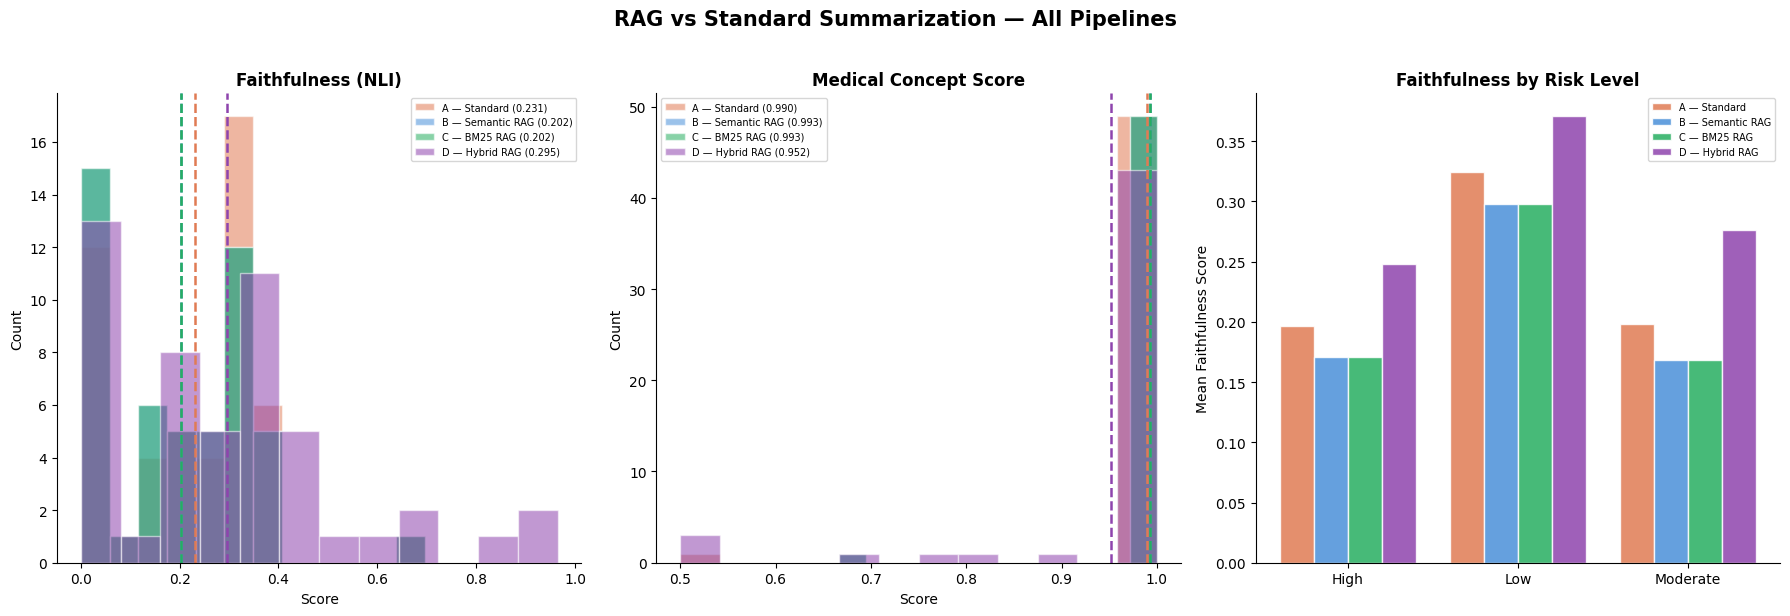

✅ Plots saved as rag_experiment_plots.png


In [18]:
# ============================================================
# CELL 12: Three publication-ready plots
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

COLORS = {
    "A — Standard"   : "#e07b54",
    "B — Semantic RAG": "#4a90d9",
    "C — BM25 RAG"   : "#27ae60",
    "D — Hybrid RAG" : "#8e44ad",
}

pipeline_map = {
    "A — Standard"   : ("std",  "#e07b54"),
    "B — Semantic RAG": ("sem",  "#4a90d9"),
    "C — BM25 RAG"   : ("bm25", "#27ae60"),
    "D — Hybrid RAG" : ("hyb",  "#8e44ad"),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("RAG vs Standard Summarization — All Pipelines",
             fontsize=15, fontweight="bold", y=1.02)

# ── Plot 1: Faithfulness score distribution ───────────────────
ax = axes[0]
for p_name, (p_key, color) in pipeline_map.items():
    ax.hist(df[f"{p_key}_faith"], bins=12, alpha=0.55, color=color,
            label=f"{p_name} ({df[f'{p_key}_faith'].mean():.3f})", edgecolor="white")
    ax.axvline(df[f"{p_key}_faith"].mean(), color=color, linestyle="--", linewidth=1.8)
ax.set_title("Faithfulness (NLI)", fontsize=12, fontweight="bold")
ax.set_xlabel("Score"); ax.set_ylabel("Count")
ax.legend(fontsize=7); ax.spines[["top","right"]].set_visible(False)

# ── Plot 2: Medical concept score distribution ────────────────
ax = axes[1]
for p_name, (p_key, color) in pipeline_map.items():
    ax.hist(df[f"{p_key}_med"], bins=12, alpha=0.55, color=color,
            label=f"{p_name} ({df[f'{p_key}_med'].mean():.3f})", edgecolor="white")
    ax.axvline(df[f"{p_key}_med"].mean(), color=color, linestyle="--", linewidth=1.8)
ax.set_title("Medical Concept Score", fontsize=12, fontweight="bold")
ax.set_xlabel("Score"); ax.set_ylabel("Count")
ax.legend(fontsize=7); ax.spines[["top","right"]].set_visible(False)

# ── Plot 3: Risk-level bar chart (Faithfulness) ───────────────
ax = axes[2]
risk_order  = sorted(df["risk_level"].unique())
x           = np.arange(len(risk_order))
bar_width   = 0.2
offsets     = [-1.5, -0.5, 0.5, 1.5]

for offset, (p_name, (p_key, color)) in zip(offsets, pipeline_map.items()):
    means = [df[df["risk_level"]==r][f"{p_key}_faith"].mean() for r in risk_order]
    ax.bar(x + offset * bar_width, means, bar_width,
           label=p_name, color=color, alpha=0.85, edgecolor="white")

ax.set_title("Faithfulness by Risk Level", fontsize=12, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(risk_order)
ax.set_ylabel("Mean Faithfulness Score")
ax.legend(fontsize=7); ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("rag_experiment_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plots saved as rag_experiment_plots.png")

## Cell 13 — Qualitative Examples
Top 3 cases where Hybrid RAG improved faithfulness most — use these as case studies in your paper.

In [19]:
# ============================================================
# CELL 13: Qualitative examples
# Shows top-3 cases where Hybrid RAG improved faithfulness most
# ============================================================

df["hyb_faith_delta"] = df["hyb_faith"] - df["std_faith"]
top3 = df.nlargest(3, "hyb_faith_delta")

for rank, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"\n{'═'*72}")
    print(f"  EXAMPLE #{rank}  |  Risk Level: {row['risk_level']}  |  Sample ID: {row['id']}")
    print(f"{'═'*72}")
    print(f"\n📄 SOURCE (first 250 chars):\n{str(row['source'])[:250]}...")
    print(f"\n🔴 STANDARD SUMMARY:\n{row['std_summary']}")
    print(f"\n🟢 HYBRID RAG SUMMARY:\n{row['hybrid_summary']}")
    print(f"\n📋 REFERENCE SUMMARY:\n{row['reference']}")
    print(f"\n📊 Faithfulness : Std={row['std_faith']:.3f}  Hyb={row['hyb_faith']:.3f}  Δ={row['hyb_faith_delta']:+.3f}")
    print(f"   Med Concept  : Std={row['std_med']:.3f}  Hyb={row['hyb_med']:.3f}")
    print(f"   BERTScore    : Std={row['std_bert']:.3f}  Hyb={row['hyb_bert']:.3f}")


════════════════════════════════════════════════════════════════════════
  EXAMPLE #1  |  Risk Level: Low  |  Sample ID: 43
════════════════════════════════════════════════════════════════════════

📄 SOURCE (first 250 chars):
Intermittent episodes of postprandial upper abdominal discomfort. Physical examination demonstrates mild epigastric tenderness and normal bowel sounds. No acute instability is detected....

🔴 STANDARD SUMMARY:
Intermittent episodes of postprandial upper abdominal discomfort. Physical examination demonstrates mild epigastric tenderness and normal bowel sounds.

🟢 HYBRID RAG SUMMARY:
Structured clinical findings:                postprandial upper abdominal discomfort; mild epigastric tenderness; normal bowel sounds. No acute instability is detected.

📋 REFERENCE SUMMARY:
Clinical progression indicates altered gastrointestinal motility and transient luminal distension dynamics. Temporal classification as chronic aligns with the documented objective features. Risk le

## Cell 14 — Save Results

In [20]:
# ============================================================
# CELL 14: Save full results to CSV and download
# ============================================================

csv_path = "rag_full_experiment_results.csv"
df.to_csv(csv_path, index=False)
print(f"✅ Results saved to {csv_path}")
print(f"   Rows    : {len(df)}")
print(f"   Columns : {len(df.columns)}")

# Download files to your local machine
from google.colab import files
files.download(csv_path)
files.download("rag_experiment_plots.png")
print("\n✅ Downloads started")

✅ Results saved to rag_full_experiment_results.csv
   Rows    : 50
   Columns : 33


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Downloads started


## Cell 15 — Paper Interpretation Guide

In [21]:
# ============================================================
# CELL 15: Auto-generates your results section text
# ============================================================

from scipy import stats

def pipeline_summary(p_key, p_name):
    faith_mean = df[f"{p_key}_faith"].mean()
    med_mean   = df[f"{p_key}_med"].mean()
    bert_mean  = df[f"{p_key}_bert"].mean()

    if p_key != "std":
        _, faith_p = stats.ttest_rel(df[f"{p_key}_faith"], df["std_faith"])
        _, med_p   = stats.ttest_rel(df[f"{p_key}_med"],   df["std_med"])
        faith_delta = faith_mean - df["std_faith"].mean()
        med_delta   = med_mean   - df["std_med"].mean()
        sig_faith   = "significant" if faith_p < 0.05 else "not significant"
        sig_med     = "significant" if med_p   < 0.05 else "not significant"
        return (f"{p_name}: Faithfulness={faith_mean:.3f} (Δ={faith_delta:+.3f}, {sig_faith}), "
                f"Medical Concept={med_mean:.3f} (Δ={med_delta:+.3f}, {sig_med}), "
                f"BERTScore={bert_mean:.3f}")
    else:
        return (f"{p_name}: Faithfulness={faith_mean:.3f} [baseline], "
                f"Medical Concept={med_mean:.3f} [baseline], "
                f"BERTScore={bert_mean:.3f} [baseline]")

print("=" * 72)
print("  RESULTS SECTION — COPY INTO YOUR PAPER")
print("=" * 72)

for p_key, p_name in [("std","A — Standard"), ("sem","B — Semantic RAG"),
                       ("bm25","C — BM25 RAG"), ("hyb","D — Hybrid RAG")]:
    print(f"\n{pipeline_summary(p_key, p_name)}")

# Risk-level highlight
print("\n" + "─"*72)
print("RISK-LEVEL HIGHLIGHT (Hybrid RAG vs Standard):")
for risk in sorted(df["risk_level"].unique()):
    sub = df[df["risk_level"]==risk]
    delta = sub["hyb_faith"].mean() - sub["std_faith"].mean()
    print(f"  {risk:8}: Faithfulness Δ = {delta:+.4f}")

print("""
─────────────────────────────────────────────────────────────────────────
SUGGESTED ABSTRACT FRAMING:
  We evaluate four summarization pipelines on a clinical notes benchmark:
  standard LLM summarization and three RAG variants (Semantic, BM25, Hybrid).
  We assess factual consistency using an NLI-based faithfulness score,
  medical concept preservation via scispaCy, and semantic similarity via
  BERTScore. Risk-stratified analysis reveals whether RAG improvements
  scale with patient risk level, providing clinical safety insights beyond
  standard NLP benchmarks.
─────────────────────────────────────────────────────────────────────────
""")

  RESULTS SECTION — COPY INTO YOUR PAPER

A — Standard: Faithfulness=0.231 [baseline], Medical Concept=0.990 [baseline], BERTScore=0.846 [baseline]

B — Semantic RAG: Faithfulness=0.202 (Δ=-0.029, significant), Medical Concept=0.993 (Δ=+0.003, not significant), BERTScore=0.846

C — BM25 RAG: Faithfulness=0.202 (Δ=-0.029, significant), Medical Concept=0.993 (Δ=+0.003, not significant), BERTScore=0.846

D — Hybrid RAG: Faithfulness=0.295 (Δ=+0.064, significant), Medical Concept=0.952 (Δ=-0.038, significant), BERTScore=0.839

────────────────────────────────────────────────────────────────────────
RISK-LEVEL HIGHLIGHT (Hybrid RAG vs Standard):
  High    : Faithfulness Δ = +0.0513
  Low     : Faithfulness Δ = +0.0467
  Moderate: Faithfulness Δ = +0.0780

─────────────────────────────────────────────────────────────────────────
SUGGESTED ABSTRACT FRAMING:
  We evaluate four summarization pipelines on a clinical notes benchmark:
  standard LLM summarization and three RAG variants (Semantic, 